# The effects of Internet adoption on GDP and Happiness

## Project Summary

The purpose of this project is to uncover any correlations between the adoption of internet and GDP, futhermore we will look at the effects on happiness. We will be looking at charts that will demonstrate relationships between the data as well as conducting cluster analysis to see what key differences can be found between countries.
 The data was retrieved from Kaggle.com using the "Internet Prices Datasets for Analysis" and "World Happiness report". The data was joined into a single csv file using Postgresql on pgadmin4. The data was taken from 2015 to 2019 highliting an era of growing worldwide adoption of the internet and highlites its impacts on nations GDP, wages and happiness. The data was also aggregated to allow us to analyze the changes over the course of these five years.


## Enviroment set_up and Data loading

In [439]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import zscore
from sklearn.cluster import KMeans
import statsmodels.api as sm
import seaborn as sns
%matplotlib inline

df = pd.read_csv("GDP_Happiness_Internet_dataset.csv")
df.describe()
#df.head()
df.dropna()

,internet_use_proportion,five_yr_internet_growth,internet_growth_percent,gdp,five_yr_gdp_growth,gdp_growth_percent,avg_wages,five_yr_wage_growth,wage_growth_percent,happiness_score,happiness_change
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,84.000000,84.000000
mean,79.490805,11.446322,0.176667,24389.136782,2599.966667,0.110115,1358.948046,51.871954,-0.000575,5.968762,0.040143
std,17.395551,7.597065,0.142557,23608.678570,3567.481612,0.134800,1133.412642,241.954435,0.283041,0.949820,0.345539
min,24.800000,0.520000,0.010000,1195.000000,-3712.700000,-0.370000,207.760000,-434.780000,-1.700000,4.015000,-0.683000
25%,72.105000,5.865000,0.060000,6320.550000,346.650000,0.040000,472.655000,-107.130000,-0.110000,5.251500,-0.195750
50%,84.600000,10.200000,0.150000,15732.200000,1443.400000,0.120000,914.440000,26.280000,0.030000,6.018000,0.007000
75%,91.115000,16.835000,0.250000,41640.000000,4110.500000,0.205000,2340.085000,200.285000,0.145000,6.750750,0.246750
max,100.000000,43.200000,0.720000,113218.700000,18874.100000,0.420000,5613.730000,1132.360000,0.510000,7.769000,0.958000


## Country Segmentation

First I will start by clustering the data to see how we can better define the wide range of countries in our dataset and see what kind of common characteristics they each contain. I decided to use Kmeans clustering and created an elbow plot to determin the best number of clusters to includeing

C:\Users\chadh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chadh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chadh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chadh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

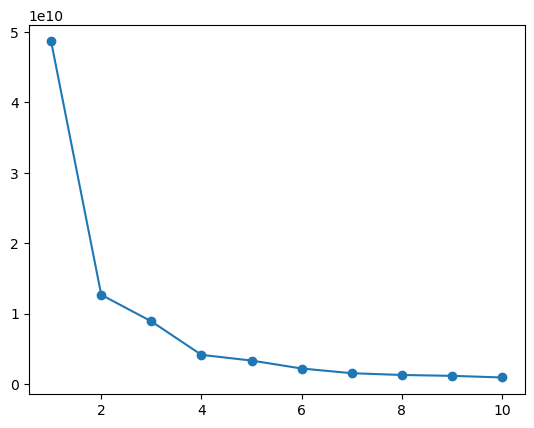

In [424]:
cluster_data = df.iloc[:, 1:].dropna(axis= 0)
k_range = range(1,11)
inertia_values = []

for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state= 42, n_init= 'auto')
    kmeans.fit(cluster_data)
    inertia_values.append(kmeans.inertia_)


plt.plot(k_range, inertia_values, marker = 'o', linestyle= '-')

I decided to use 4 clusters becuase the change from 2 to 3 and 3 to 4 is similar and as for every cluster created after 4 the change is only minimal. Next I will create the clusters and observe the data to determine what significant differences there are.

In [521]:
kmeans_model = KMeans(n_clusters = 4, random_state =42, n_init='auto')
kmeans_model.fit(cluster_data)
clusters = pd.DataFrame(kmeans_model.cluster_centers_)
col_names = cluster_data.columns
clusters.columns = col_names

kmeans_labels = kmeans_model.labels_
cluster_data['cluster_id'] = kmeans_labels


clusters

C:\Users\chadh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,internet_use_proportion,five_yr_internet_growth,internet_growth_percent,gdp,five_yr_gdp_growth,gdp_growth_percent,avg_wages,five_yr_wage_growth,wage_growth_percent,happiness_score,happiness_change,cluster_id
0,86.566,10.25700,0.12150,22748.200,3723.260,0.1660,1173.08850,92.13300,0.09400,6.102850,0.263100,2.220446e-16
1,92.773,4.80400,0.05400,51073.445,5055.505,0.0975,2797.28550,219.71500,0.07700,6.955750,-0.030750,1.000000e+00
2,67.465,15.94575,0.27875,6232.970,567.070,0.0965,503.44475,-34.50425,-0.08175,5.276475,-0.035625,2.000000e+00
3,95.505,2.77750,0.03000,88789.900,7138.375,0.0825,3894.63500,14.48000,0.01000,7.286250,0.037500,3.000000e+00


<Axes: xlabel='cluster_id', ylabel='count'>

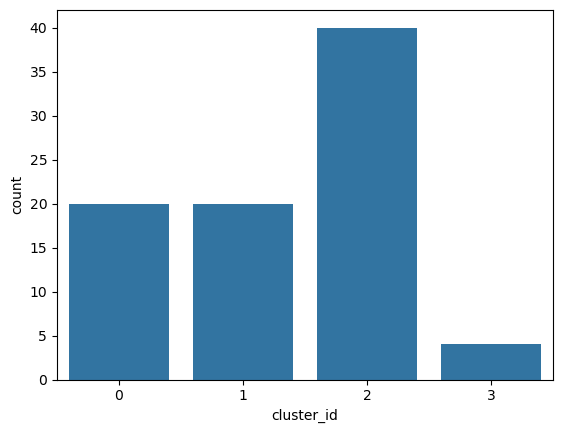

In [407]:
sns.countplot(cluster_data, x = 'cluster_id')

Cluster 0 is characterized by moderate internet growth and adoption, high gdp_growth_percent,  high wage_growth_percent, high happiness_change (growing nations)
Cluster 1 has higher internet proportion, high wage growth, high happiness(Economically expanding nations)
Cluster 2 has low internet_proportion, high internet adoption, low gdp, low gdp growth, low wages, declining wage_growth and declining happiness (declining nations)
Cluster 3 has high internet_proportion, high GDP, high gdp_growth, high wages and high happiness (Titan Nations)



## Internet Growth

In [441]:
df['five_yr_internet_growth'].describe()
df['internet_growth_percent'].describe()
df[df['internet_growth_percent']== .72] #Iraq had the largest internet adoption growth

,country,internet_use_proportion,five_yr_internet_growth,internet_growth_percent,gdp,five_yr_gdp_growth,gdp_growth_percent,avg_wages,five_yr_wage_growth,wage_growth_percent,happiness_score,happiness_change
36,Iraq ...,70.63,43.2,0.72,5943.5,1255.2,0.21,612.44,-111.64,-0.18,4.437,-0.24


All countries adopted at least a little bit with the lowest amount equal to .52 of the proportion gaining access to the internet. The average growth in internet_use_proportion was 11.5. There is also the presence of large outliers skewing the mean to the right of the median

Iraq had the largest internet adoption but also had declining wages and declining happiness.
 Important to note that Internet adoption is not the only variable at play with a country like Iraq that has a lot of societal conflict may have
 a large impact on wages and happiness

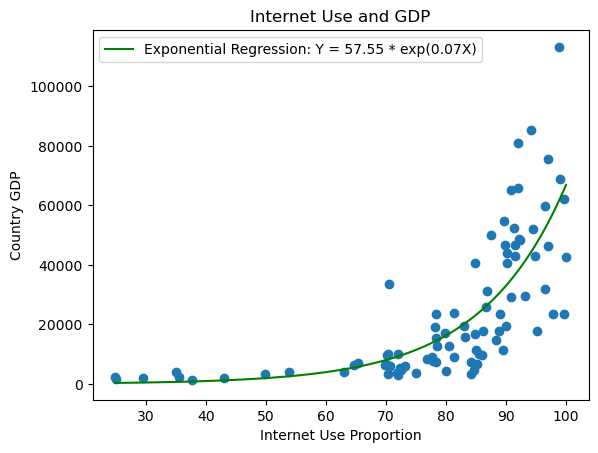

In [445]:
x_plot = np.linspace(df['internet_use_proportion'].min(), df['internet_use_proportion'].max(), 87)

def exp_func(x, a, b):
    return a* np.exp(b * x)
initial_guess = [1100, .2]

params, covariance = curve_fit(exp_func, df['internet_use_proportion'], df['gdp'], p0= initial_guess)
a_optimal, b_optimal = params
predicted_curve_fit = exp_func(x_plot, a_optimal, b_optimal)




plt.scatter(df['internet_use_proportion'],  df['gdp'])
plt.plot(x_plot, predicted_curve_fit, color= 'green', label = f"Exponential Regression: Y = {a_optimal:.2f} * exp({b_optimal:.2f}X)" )
plt.legend()
plt.title('Internet Use and GDP')
plt.xlabel("Internet Use Proportion")
plt.ylabel("Country GDP")
plt.show()

In [160]:
df['internet_use_proportion'].corr(df['gdp'], method = 'spearman')

0.8512598533182549

We can see that there is a strong exponential relationship between Internet use and GDP, but we can not apply causation. Next we will look at the rate of internet adoption with the rate of gdp growth.

The correlation between these variables is  -0.3676646284102635


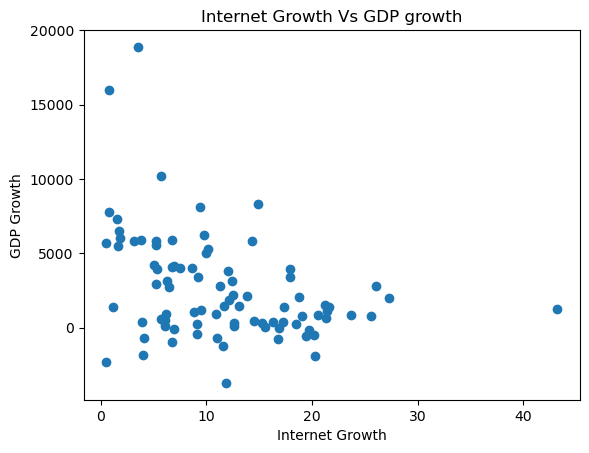

In [480]:

plt.scatter(df['five_yr_internet_growth'], df['five_yr_gdp_growth'])
plt.title('Internet Growth Vs GDP growth')
plt.xlabel('Internet Growth')
plt.ylabel('GDP Growth')
print('The correlation between these variables is ', df['five_yr_internet_growth'].corr(df['five_yr_gdp_growth']))


We can see that countries who experienced greater adoption of the internet did not necessarily experience a reciprocal growth in GDP over the span of 5 years. In fact there is a weak negative correlation between rate of internet adoption and rate of GDP growth. We do not have evidence to suggest that internet adoption increases a countries GDP but rather there is a correlation between countries that have a high internet_use_proportion and their GDP.

The correlation between these variables is  0.83


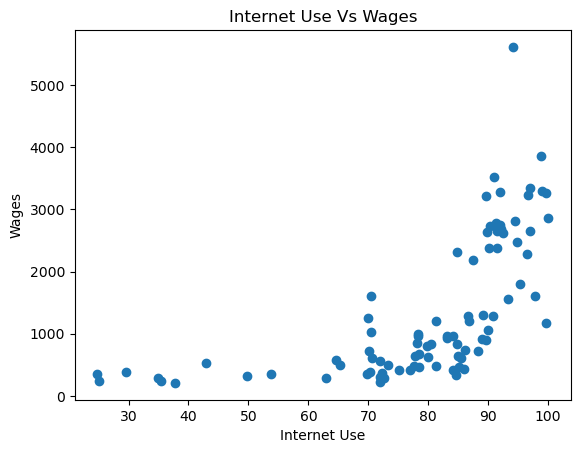

In [500]:
plt.scatter(df['internet_use_proportion'], df['avg_wages'])
plt.title('Internet Use Vs Wages')
plt.xlabel('Internet Use')
plt.ylabel('Wages')
print('The correlation between these variables is ', round(df['internet_use_proportion'].corr(df['avg_wages'], method = 'spearman'),2))

The correlation between these variables is  -0.28


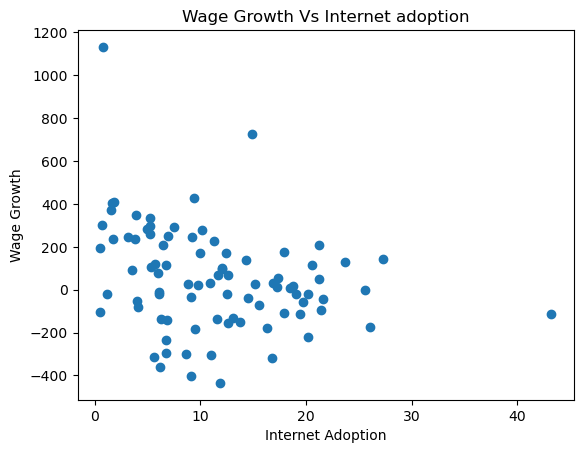

In [498]:

plt.scatter(df['five_yr_internet_growth'],df['five_yr_wage_growth']) 
plt.title('Wage Growth Vs Internet adoption')
plt.xlabel('Internet Adoption')
plt.ylabel('Wage Growth')
print('The correlation between these variables is ', round(df['five_yr_wage_growth'].corr(df['five_yr_internet_growth']),2))

Similaraly we see that countries with high_internet adoption are highly correlated with the avg_wages but we do not see a reciproval growth of wages with internet adoption.

## Happiness

The correlation between these two variable is  0.65


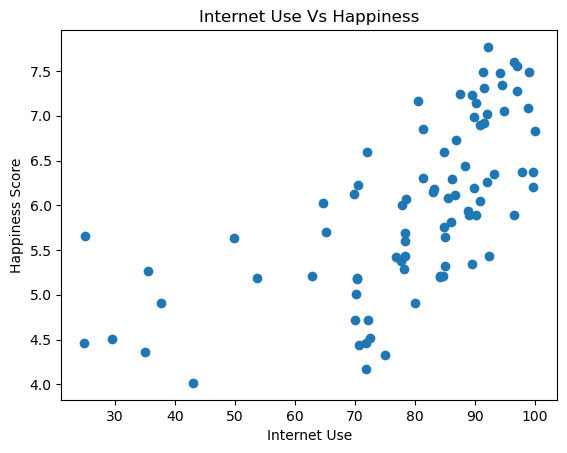

In [506]:
plt.scatter(df['internet_use_proportion'], df['happiness_score'])
plt.title('Internet Use Vs Happiness')
plt.xlabel('Internet Use')
plt.ylabel('Happiness Score')
print('The correlation between these two variable is ', round(df['internet_use_proportion'].corr(df['happiness_score']),2))

At first glance it appears that there is a strong positive correlation between happiness and internet use, but can we attribute happiness to internet adoption?

In [317]:
x = sm.add_constant(df['internet_use_proportion'],prepend = True)
y = df["happiness_score"].notna()
lm_model = sm.OLS(y, x)
results = lm_model.fit()
print(results.summary())

df['five_yr_internet_growth'].corr(df['happiness_change'])

                            OLS Regression Results                            
Dep. Variable:        happiness_score   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.1090
Date:                Fri, 13 Jun 2025   Prob (F-statistic):              0.742
Time:                        13:27:16   Log-Likelihood:                 24.612
No. Observations:                  87   AIC:                            -45.22
Df Residuals:                      85   BIC:                            -40.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

-0.25169501661405375

We see after we run a regression model on our data that there is actually a slightly negative coefficient and correlation between internet growth and 
happiness change is also negative. The R-squared tells us that Internet Use actually describes a miniscual amount of the variablity we see in the happiness score.

                            OLS Regression Results                            
Dep. Variable:       happiness_change   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1.851
Date:                Tue, 17 Jun 2025   Prob (F-statistic):              0.177
Time:                        17:37:18   Log-Likelihood:                 25.493
No. Observations:                  87   AIC:                            -46.99
Df Residuals:                      85   BIC:                            -42.05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.9598    

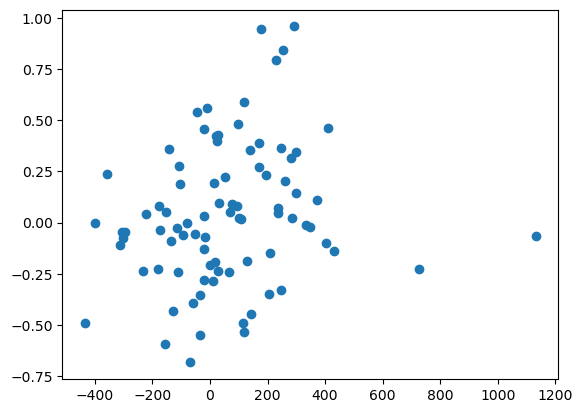

In [512]:
plt.scatter(df['five_yr_wage_growth'], df['happiness_change'])

x = sm.add_constant(df['five_yr_wage_growth'],prepend = True)
y = df["happiness_change"].notna()
lm_model = sm.OLS(y, x)
wage_happiness_results = lm_model.fit()
print(wage_happiness_results.summary())

And we can see here that as wages increase there is little change in happiness, and that wage growth does not encapsulate nearly any of the variablity in happiness change over a five year span. 

## Summary

In summary we can conclude that there is little evidence to suggest that a countries GDP or happiness will increase with the adoption of the internet by its citizens. We observed that countries with higher GDP tend to have a higher proportion of internet users, but that a five year change in growing internet adoption did not yield a similar increase in GDP. Again, with wages we observed that countries with a higher proprtion of internet users tend to have higher average wages, but we did not see any correlation between the growth of internet and wages. 

We saw that coutries with more internet users tended to be happier coutries but when we ran a regression model we could not attribute any change in happiness to internet adoption. Nor could we attribute any changes in wages to happiness. 

These findings should not come as too much of a suprise, a countries GDP can be affected my many, many different variable including economic policy, civil strife, resource limitations, etc. While the adoption of internet by a countries citizens may be able to help certain countries in certain situations it is not a blanket solution to increasing GDP. It is the same with happiness, we know that happiness can be affected by health, family, cultural tradions and so many more variables. We have demonstrated here that internet adoption alone does not increase how content citizens may be in their country. 

Recomendations would be for furthure analysis on a more micro level. Instead of looking at these variables from a global perpective we could dive in deeper to look at the impacts on internet adoption in rural towns vs growing cities. We could look more closely at the individual citizens to see the impacts of internet access on their happiness. Uncovering whether or not the internet plays a part in peoples happiness, either directly or indirectly by allowing the use of online tools to increase wages, could allow developers, communications companies, to uncover how they might better be able offer tools or design their webspaces to increase the users overall happiness with their brand. Even local governments could use this information to make decisions on investing in internet infastructure. 